# Reproducing figure 1

Let's pull together all the different approaches we have tried and try to recreate that figure 1 plot.

In [1]:
%load_ext autoreload
%autoreload 2
import components.reference as ref
import components.odil as odil
import components.pinn as pinn

First, let's get the exact solution for the ODIL and PINN approach comparisons. ODIL is performed on a $25 \times 25$ grid, and the PINN has an arbitrary resolution, but let's evaluate it on a $100 \times 100$ grid.

In [2]:
import numpy as np

In [3]:
x_0 = -1.0; x_N = 1.0
t_0 = 0.0; t_I = 1.0
N = I = 25

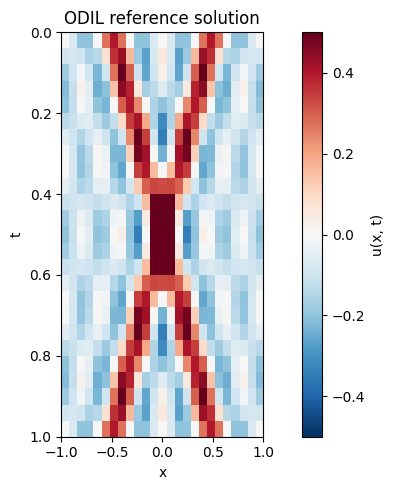

In [4]:
x_odil = np.linspace(x_0, x_N, N)
t_odil = np.linspace(t_0, t_I, I)
u_exact_odil = ref.get_exact(t_odil, x_odil)

ref.plot_1d(u_exact_odil, x_odil, t_odil, title="ODIL reference solution")

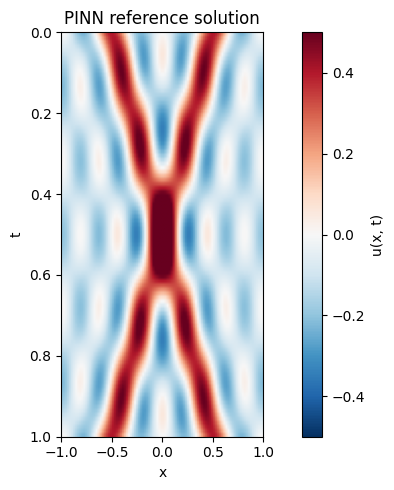

In [5]:
x_pinn = np.linspace(x_0, x_N, 4*N)
t_pinn = np.linspace(t_0, t_I, 4*I)
u_exact_pinn = ref.get_exact(t_pinn, x_pinn)

ref.plot_1d(u_exact_pinn, x_pinn, t_pinn, title="PINN reference solution")

In [6]:
# store these in a dictionary for later
solutions = {'odil-ref': u_exact_odil, 'pinn-ref': u_exact_pinn}

Now, let's obtain our ODIL result using Newton's method.

Convergence:  achieved
Exit reason: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Iterations: 48565
Wall time: 117.62932062149048


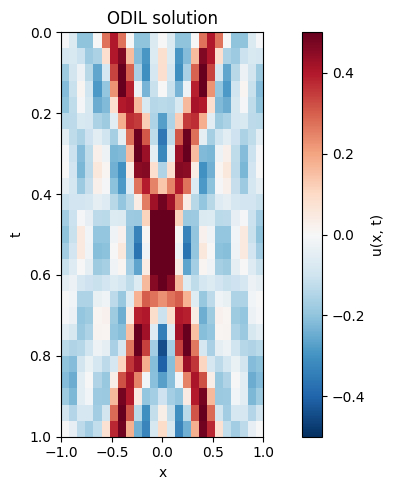

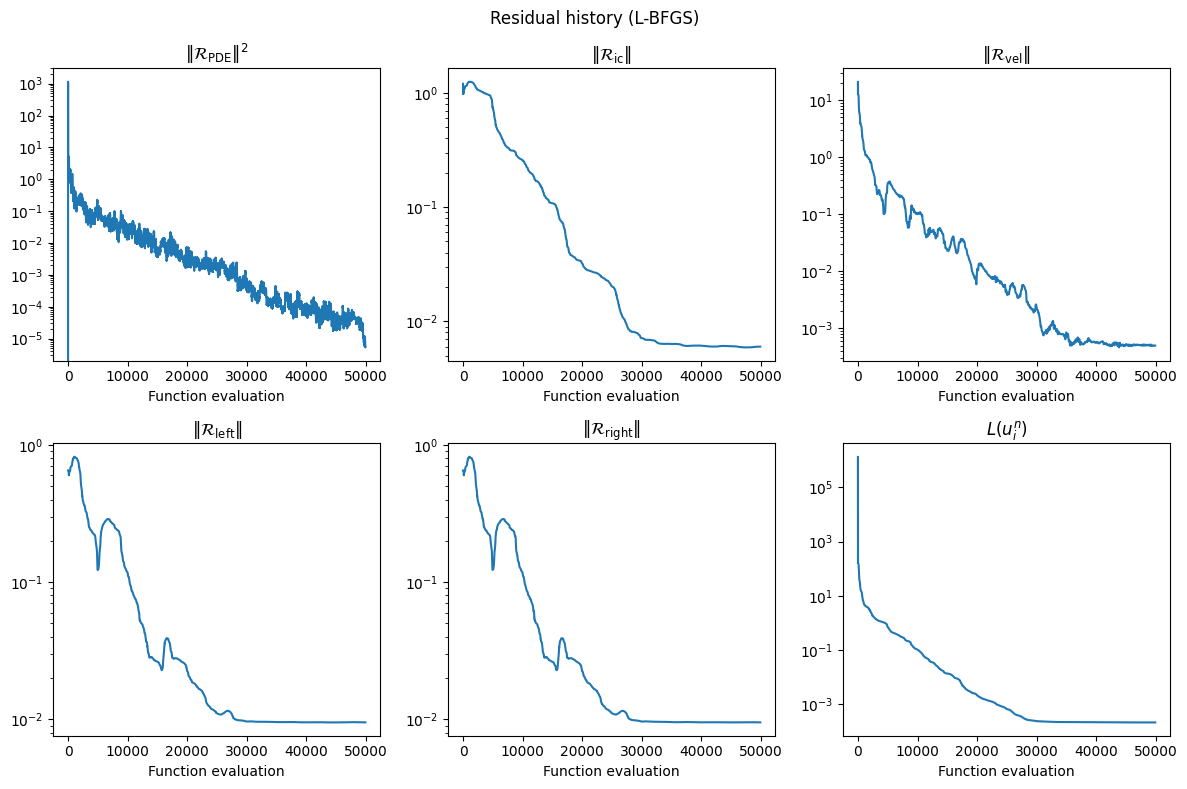

In [7]:
u = odil.run_odil(field_plot_title="ODIL solution", history_plot_title="Residual history (L-BFGS)")

In [8]:
# reshape from flattened and store
u_odil = u.data.reshape(N, I) # time, space
solutions['odil-result'] = u_odil

Now, we can train up our PINN and use it to get solutions on the reference grid.

In [15]:
conf = pinn.PINNConfig()
conf.seed = 7 # best seed found from sweep
conf.epochs = 2000
conf.layers = 2
conf.neurons = 25
conf.ic_weight = 5.0
conf.left_bc_weight = 5.0
conf.right_bc_weight = 5.0
conf.velocity_bc_weight = 15.0
conf.pde_weight = 1.0

In [ ]:
pinn.train(config=conf)